# Spotify Popularity Research: Random Forest Regression

This notebook tries Random Forest regression on the same Kaggle-derived Spotify dataset and the same 80% training / 20% testing split used in the previous kNN notebooks.

It compares four models on the held-out test set:

1. Mean baseline.
2. Filtered kNN regression from the previous research setup.
3. Random Forest using only the correlation-filtered predictors.
4. Random Forest using the full engineered predictor set.

The full-feature Random Forest is included because tree ensembles can often ignore weak predictors internally and still use nonlinear interactions that a simple correlation filter may remove.


In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
LOW_CORRELATION_THRESHOLD = 0.05

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 140)
pd.set_option('display.width', 160)


## 1. Load the Dataset

The notebook uses `cleaned.csv`, the cleaned Kaggle Spotify Tracks dataset already present in this project.


In [2]:
DATA_PATH = Path('cleaned.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('dataset.csv')

df = pd.read_csv(DATA_PATH)
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

if 'duration_min' not in df.columns and 'duration_ms' in df.columns:
    df['duration_min'] = df['duration_ms'] / 60_000

if df['explicit'].dtype == bool:
    df['explicit'] = df['explicit'].astype(int)

print(f'Loaded {DATA_PATH.name}: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Missing values: {int(df.isna().sum().sum()):,}')
print(f'Popularity range: {df["popularity"].min()} to {df["popularity"].max()}')
display(df.head())


Loaded cleaned.csv: 89,740 rows x 21 columns
Missing values: 0
Popularity range: 0 to 100


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min
0,3nqQXoyQOWXiESFLlDF1hG,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),Unholy (feat. Kim Petras),100,156943,0,0.714,0.472,2,-7.375,1,0.0864,0.01300,0.000005,0.266,0.238,131.121,4,dance,2.62
1,2tTmW7RDtMQtBk7m2rYeSw,Bizarrap;Quevedo,"Quevedo: Bzrp Music Sessions, Vol. 52","Quevedo: Bzrp Music Sessions, Vol. 52",99,198937,0,0.621,0.782,2,-5.548,1,0.0440,0.01250,0.033000,0.230,0.550,128.033,4,hip-hop,3.32
2,5ww2BF9slyYgNOk37BlC4u,Manuel Turizo,La Bachata,La Bachata,98,162637,0,0.835,0.679,7,-5.329,0,0.0364,0.58300,0.000002,0.218,0.850,124.980,4,reggaeton,2.71
3,4uUG5RXrOk84mYEfFvj3cK,David Guetta;Bebe Rexha,I'm Good (Blue),I'm Good (Blue),98,175238,1,0.561,0.965,7,-3.673,0,0.0343,0.00383,0.000007,0.371,0.304,128.040,4,pop,2.92
4,1IHWl5LamUGEuP4ozKQSXZ,Bad Bunny,Un Verano Sin Ti,Tití Me Preguntó,97,243716,0,0.650,0.715,5,-5.198,0,0.2530,0.09930,0.000291,0.126,0.187,106.672,4,latino,4.06


## 2. Build Candidate Features and Split 80/20

Identifiers and text metadata are excluded. Numeric/audio variables are used directly. `track_genre` is one-hot encoded into genre indicators.


In [3]:
numeric_features = [
    'duration_min', 'explicit', 'danceability', 'energy', 'key', 'loudness',
    'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo', 'time_signature',
]

categorical_feature = 'track_genre'
target = 'popularity'

model_df = df[numeric_features + [categorical_feature, target]].dropna().copy()
X = model_df[numeric_features + [categorical_feature]]
y = model_df[target].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

X_train_genre = pd.get_dummies(X_train[categorical_feature], prefix='genre', dtype=float)
X_test_genre = pd.get_dummies(X_test[categorical_feature], prefix='genre', dtype=float).reindex(
    columns=X_train_genre.columns, fill_value=0.0
)

X_train_full = pd.concat([X_train[numeric_features], X_train_genre], axis=1)
X_test_full = pd.concat([X_test[numeric_features], X_test_genre], axis=1)

print(f'Research dataset: {model_df.shape[0]:,} rows')
print(f'Training set: {X_train.shape[0]:,} rows ({X_train.shape[0] / len(X):.1%})')
print(f'Testing set:  {X_test.shape[0]:,} rows ({X_test.shape[0] / len(X):.1%})')
print(f'Full engineered predictors: {X_train_full.shape[1]:,}')


Research dataset: 89,740 rows
Training set: 71,792 rows (80.0%)
Testing set:  17,948 rows (20.0%)
Full engineered predictors: 128


## 3. Reuse the Correlation Filter

The same training-only filter from the previous notebook is applied: keep predictors with `|Pearson r| >= 0.05` against popularity. This produces the filtered feature set used by filtered kNN and filtered Random Forest.


In [4]:
feature_correlations = X_train_full.corrwith(y_train).dropna()
feature_correlations = feature_correlations.sort_values(key=lambda values: values.abs(), ascending=False)

selected_features = feature_correlations[
    feature_correlations.abs() >= LOW_CORRELATION_THRESHOLD
].index.tolist()
dropped_features = feature_correlations[
    feature_correlations.abs() < LOW_CORRELATION_THRESHOLD
].index.tolist()

selected_numeric_features = [feature for feature in numeric_features if feature in selected_features]
dropped_numeric_features = [feature for feature in numeric_features if feature not in selected_features]
selected_genre_features = [feature for feature in selected_features if feature.startswith('genre_')]

X_train_filtered = X_train_full[selected_features]
X_test_filtered = X_test_full[selected_features]

print(f'Correlation cutoff: |r| >= {LOW_CORRELATION_THRESHOLD}')
print(f'Selected filtered predictors: {len(selected_features):,} of {len(feature_correlations):,}')
print(f'Selected original numeric features: {selected_numeric_features}')
print(f'Dropped original numeric features: {dropped_numeric_features}')
print(f'Selected genre indicators: {len(selected_genre_features)}')

display(pd.DataFrame({
    'feature': feature_correlations.index,
    'training_correlation': feature_correlations.values,
    'selected': feature_correlations.index.isin(selected_features),
}).head(20).style.format({'training_correlation': '{:.4f}'}))


Correlation cutoff: |r| >= 0.05
Selected filtered predictors: 44 of 128
Selected original numeric features: ['explicit', 'danceability', 'loudness', 'instrumentalness']
Dropped original numeric features: ['duration_min', 'energy', 'key', 'mode', 'speechiness', 'acousticness', 'liveness', 'valence', 'tempo', 'time_signature']
Selected genre indicators: 40


,feature,training_correlation,selected
0,genre_iranian,-0.1596,True
1,genre_romance,-0.1475,True
2,instrumentalness,-0.1283,True
3,genre_k-pop,0.1248,True
4,genre_detroit-techno,-0.1114,True
5,genre_chicago-house,-0.1097,True
6,genre_pop-film,0.1087,True
7,genre_jazz,-0.1065,True
8,genre_classical,-0.1016,True
9,genre_grindcore,-0.0954,True


## 4. Tune a Filtered Random Forest

A compact validation sweep chooses a Random Forest setting for the filtered predictor matrix. This is intentionally small so the notebook remains practical to rerun.


In [5]:
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train_filtered, y_train, test_size=0.20, random_state=RANDOM_STATE
)

rf_configs = [
    {'max_depth': None, 'min_samples_leaf': 1, 'max_features': 1.0},
    {'max_depth': 30, 'min_samples_leaf': 1, 'max_features': 0.8},
    {'max_depth': 20, 'min_samples_leaf': 2, 'max_features': 0.8},
    {'max_depth': 20, 'min_samples_leaf': 5, 'max_features': 0.8},
    {'max_depth': 12, 'min_samples_leaf': 5, 'max_features': 1.0},
    {'max_depth': 20, 'min_samples_leaf': 10, 'max_features': 'sqrt'},
]

validation_rows = []

for idx, config in enumerate(rf_configs, start=1):
    model = RandomForestRegressor(
        n_estimators=120,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **config,
    )
    model.fit(X_fit, y_fit)
    val_pred = model.predict(X_val)
    validation_rows.append({
        'config': idx,
        **config,
        'validation_r2': r2_score(y_val, val_pred),
        'validation_mae': mean_absolute_error(y_val, val_pred),
        'validation_rmse': np.sqrt(mean_squared_error(y_val, val_pred)),
    })

rf_validation = pd.DataFrame(validation_rows).sort_values('validation_mae')
best_rf_config = rf_validation.iloc[0][['max_depth', 'min_samples_leaf', 'max_features']].to_dict()

if pd.isna(best_rf_config['max_depth']):
    best_rf_config['max_depth'] = None
best_rf_config['min_samples_leaf'] = int(best_rf_config['min_samples_leaf'])

print('Best filtered Random Forest config by validation MAE:')
print(best_rf_config)
display(rf_validation.style.format({
    'validation_r2': '{:.3f}',
    'validation_mae': '{:.2f}',
    'validation_rmse': '{:.2f}',
}))


Best filtered Random Forest config by validation MAE:
{'max_depth': None, 'min_samples_leaf': 1, 'max_features': 1.0}


,config,max_depth,min_samples_leaf,max_features,validation_r2,validation_mae,validation_rmse
0,1,nan,1,1.000000,0.307,12.32,16.97
1,2,30.000000,1,0.800000,0.270,13.25,17.42
2,3,20.000000,2,0.800000,0.235,13.90,17.83
5,6,20.000000,10,sqrt,0.256,13.92,17.59
3,4,20.000000,5,0.800000,0.235,13.92,17.83
4,5,12.000000,5,1.000000,0.173,14.82,18.54


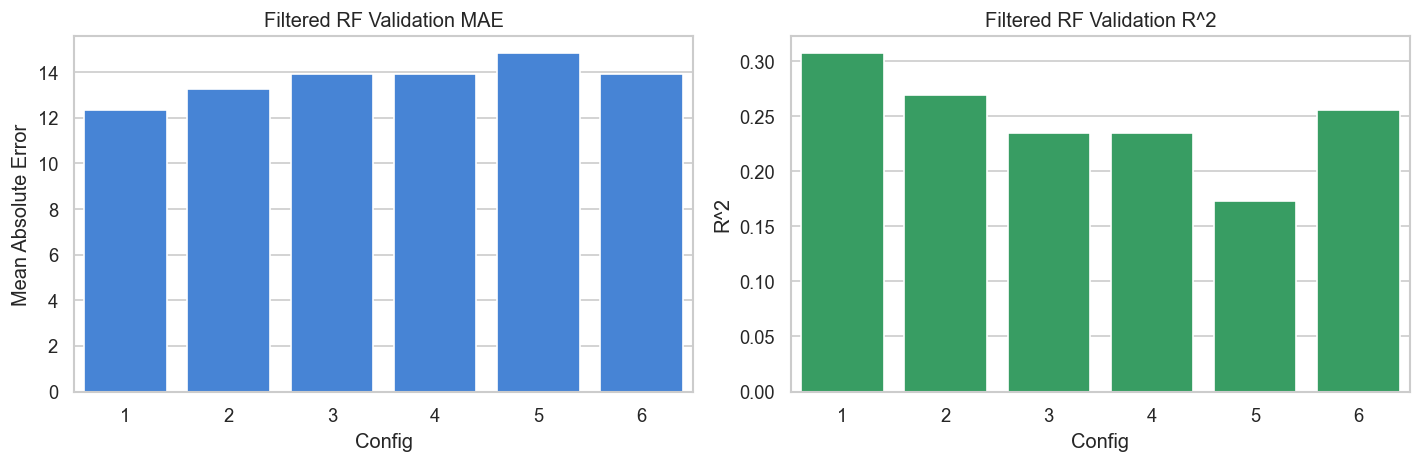

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_df = rf_validation.sort_values('config')

sns.barplot(data=plot_df, x='config', y='validation_mae', ax=axes[0], color='#2F80ED')
axes[0].set_title('Filtered RF Validation MAE')
axes[0].set_xlabel('Config')
axes[0].set_ylabel('Mean Absolute Error')

sns.barplot(data=plot_df, x='config', y='validation_r2', ax=axes[1], color='#27AE60')
axes[1].set_title('Filtered RF Validation R^2')
axes[1].set_xlabel('Config')
axes[1].set_ylabel('R^2')

plt.tight_layout()
plt.show()


## 5. Final Model Comparison on the Held-Out Test Set

The final comparison evaluates filtered kNN, filtered Random Forest, and full-feature Random Forest on the same 20% test set.


In [7]:
def regression_metrics(name, actual, predicted):
    errors = np.abs(actual - predicted)
    return {
        'model': name,
        'test_r2': r2_score(actual, predicted),
        'test_mae': mean_absolute_error(actual, predicted),
        'test_rmse': np.sqrt(mean_squared_error(actual, predicted)),
        'within_10_points': np.mean(errors <= 10),
        'within_20_points': np.mean(errors <= 20),
    }

baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train_filtered, y_train)
baseline_pred = baseline.predict(X_test_filtered)

filtered_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor(n_neighbors=151, weights='distance')),
])
filtered_knn.fit(X_train_filtered, y_train)
filtered_knn_pred = filtered_knn.predict(X_test_filtered)

filtered_rf = RandomForestRegressor(
    n_estimators=250,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **best_rf_config,
)
filtered_rf.fit(X_train_filtered, y_train)
filtered_rf_pred = filtered_rf.predict(X_test_filtered)

full_rf = RandomForestRegressor(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **best_rf_config,
)
full_rf.fit(X_train_full, y_train)
full_rf_pred = full_rf.predict(X_test_full)

comparison = pd.DataFrame([
    regression_metrics('mean baseline', y_test, baseline_pred),
    regression_metrics('filtered kNN (k=151)', y_test, filtered_knn_pred),
    regression_metrics('filtered Random Forest', y_test, filtered_rf_pred),
    regression_metrics('full-feature Random Forest', y_test, full_rf_pred),
]).sort_values('test_mae')

display(comparison.style.format({
    'test_r2': '{:.3f}',
    'test_mae': '{:.2f}',
    'test_rmse': '{:.2f}',
    'within_10_points': '{:.1%}',
    'within_20_points': '{:.1%}',
}))


,model,test_r2,test_mae,test_rmse,within_10_points,within_20_points
3,full-feature Random Forest,0.476,10.03,14.81,65.2%,86.2%
1,filtered kNN (k=151),0.375,11.47,16.17,57.4%,82.5%
2,filtered Random Forest,0.333,12.04,16.71,54.8%,81.0%
0,mean baseline,-0.000,17.11,20.46,31.9%,63.3%


## 6. Random Forest Feature Importance

The table below shows the most important predictors in the full-feature Random Forest. These importances are model-based: they describe which features the forest used most to reduce prediction error, not simple linear correlations.


,feature,importance
0,speechiness,0.0605
1,acousticness,0.0599
2,loudness,0.0595
3,duration_min,0.0591
4,danceability,0.0579
5,valence,0.0578
6,tempo,0.0559
7,energy,0.0555
8,liveness,0.0526
9,instrumentalness,0.0415


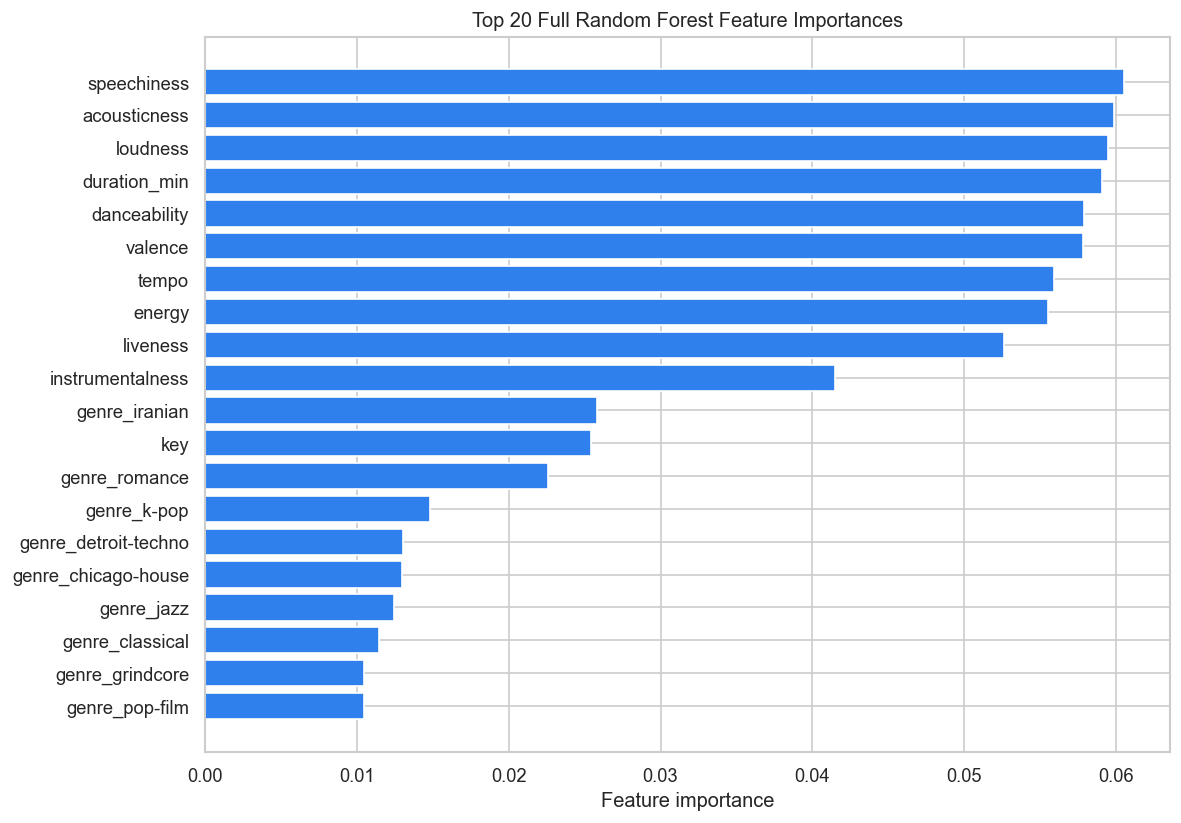

In [8]:
importance = (
    pd.Series(full_rf.feature_importances_, index=X_train_full.columns)
    .sort_values(ascending=False)
    .rename('importance')
    .reset_index()
    .rename(columns={'index': 'feature'})
)

display(importance.head(25).style.format({'importance': '{:.4f}'}))

fig, ax = plt.subplots(figsize=(10, 7))
plot_importance = importance.head(20).iloc[::-1]
ax.barh(plot_importance['feature'], plot_importance['importance'], color='#2F80ED')
ax.set_title('Top 20 Full Random Forest Feature Importances')
ax.set_xlabel('Feature importance')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


## 7. Prediction Diagnostics

The scatter plot and error histogram use the best model from this notebook: the full-feature Random Forest.


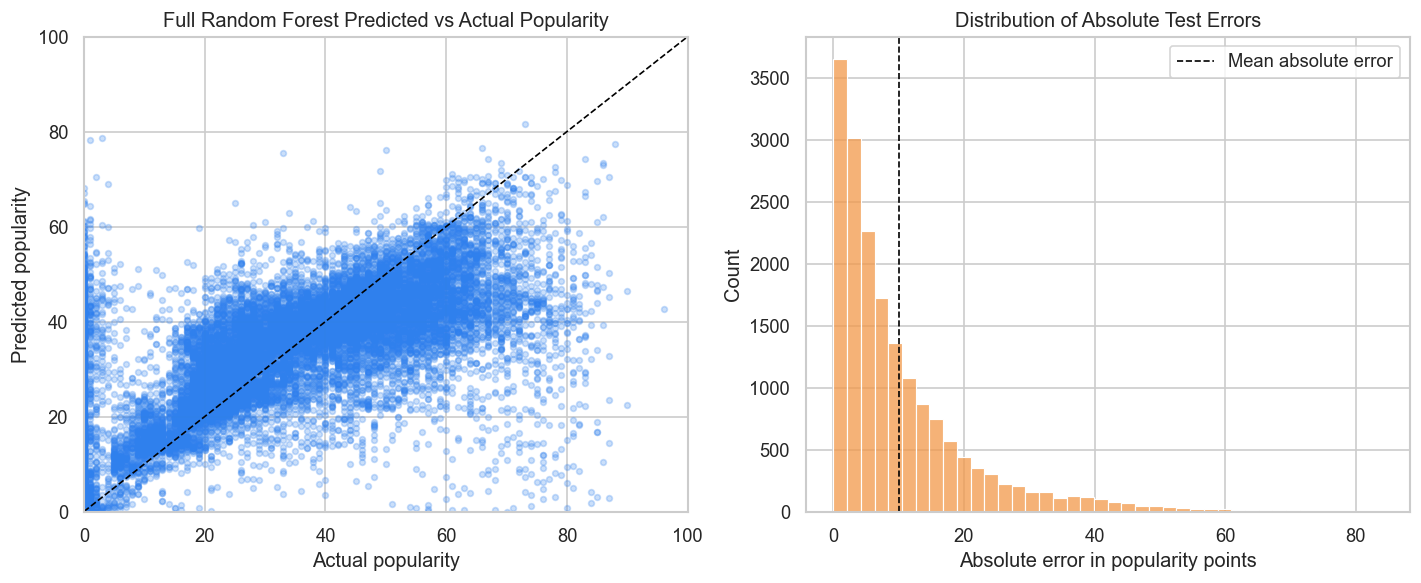

,actual_popularity,predicted_popularity,absolute_error
count,17948.00,17948.00,17948.00
mean,33.24,32.84,10.03
std,20.46,14.30,10.89
min,0.00,0.00,0.00
25%,19.00,23.53,2.65
50%,33.00,35.59,6.36
75%,49.00,42.65,13.50
max,96.00,81.60,84.06


In [9]:
evaluation = pd.DataFrame({
    'actual_popularity': y_test.values,
    'predicted_popularity': full_rf_pred,
    'absolute_error': np.abs(y_test - full_rf_pred).values,
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(evaluation['actual_popularity'], evaluation['predicted_popularity'], alpha=0.25, s=12, color='#2F80ED')
axes[0].plot([0, 100], [0, 100], color='black', linestyle='--', linewidth=1)
axes[0].set_title('Full Random Forest Predicted vs Actual Popularity')
axes[0].set_xlabel('Actual popularity')
axes[0].set_ylabel('Predicted popularity')
axes[0].set_xlim(0, 100)
axes[0].set_ylim(0, 100)

sns.histplot(evaluation['absolute_error'], bins=40, ax=axes[1], color='#F2994A')
axes[1].axvline(evaluation['absolute_error'].mean(), color='black', linestyle='--', linewidth=1, label='Mean absolute error')
axes[1].set_title('Distribution of Absolute Test Errors')
axes[1].set_xlabel('Absolute error in popularity points')
axes[1].legend()

plt.tight_layout()
plt.show()

display(evaluation.describe().round(2))


## 8. Conclusion

Random Forest improves substantially when it can use the full engineered predictor set. The filtered Random Forest is useful, but it underperforms the filtered kNN in this run. The full-feature Random Forest performs best because tree ensembles can choose useful splits and interactions even when a feature has weak marginal correlation with popularity.

This means correlation filtering is not always beneficial for tree-based models. It can help distance-based models like kNN by removing noisy dimensions, but it can remove weak-looking variables that Random Forest can still use in combination with other variables.
